# Denoising

## Training the DDPM

In [7]:
import numpy as np

class GaussianMixture:
    def __init__(self, parameters):
        self.parameters = parameters
        self.distributions = [
            {
                'mean': np.array(dist['mean']),
                'std': np.array(dist['std']),
                'cov': np.diag(np.array(dist['std']) ** 2)
            }
            for dist in parameters
        ]

    def sample(self, num_samples):
        samples = []
        num_distributions = len(self.distributions)
        for _ in range(num_samples):
            idx = np.random.randint(num_distributions)  # Choose a random Gaussian
            dist = self.distributions[idx]
            sample = np.random.multivariate_normal(mean=dist['mean'], cov=dist['cov'])
            samples.append(sample)
        return np.array(samples)

    def likelihood(self, points):
        likelihoods = np.zeros(points.shape[0])
        for dist in self.distributions:
            mean = dist['mean']
            cov = dist['cov']
            inv_cov = np.linalg.inv(cov)
            det_cov = np.linalg.det(cov)

            # Multivariate Gaussian PDF
            factor = 1 / (2 * np.pi * np.sqrt(det_cov))
            diff = points - mean
            exponents = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)
            likelihoods += factor * np.exp(exponents)

        return likelihoods

## Visualize the data

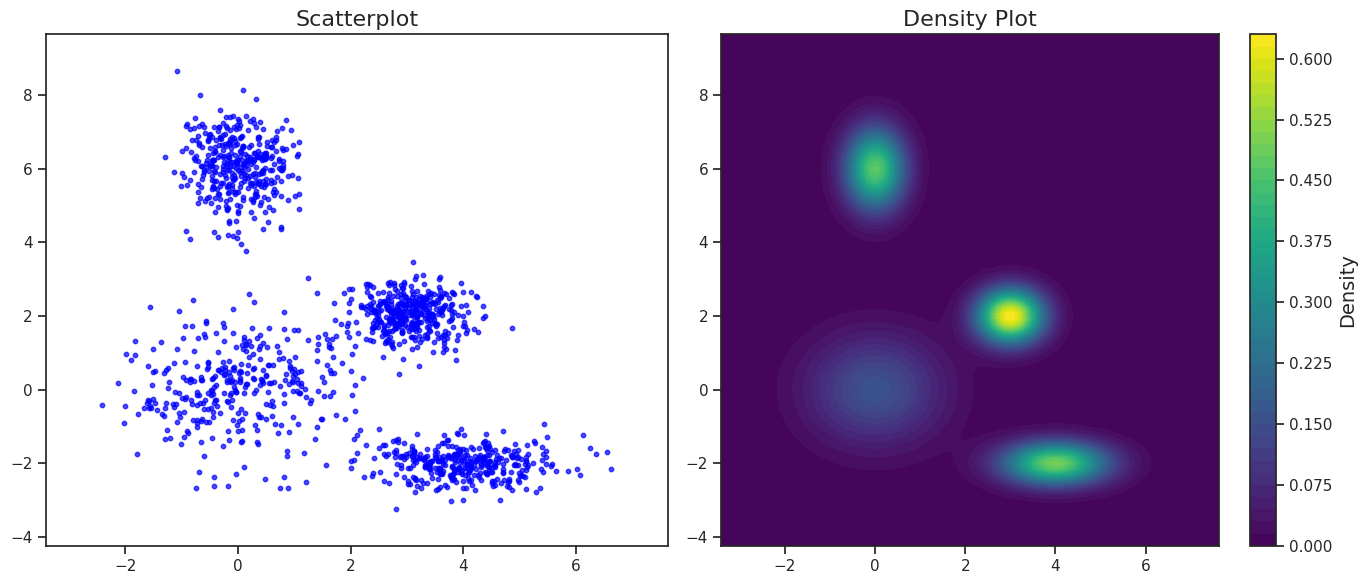

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="ticks")

def plot_gaussian_mixture(gm, samples, grid_size=100):

    x_min, x_max = np.min(samples[:, 0]) - 1, np.max(samples[:, 0]) + 1
    y_min, y_max = np.min(samples[:, 1]) - 1, np.max(samples[:, 1]) + 1
    x = np.linspace(x_min, x_max, grid_size)
    y = np.linspace(y_min, y_max, grid_size)
    X, Y = np.meshgrid(x, y)
    points = np.column_stack([X.ravel(), Y.ravel()])
    densities = gm.likelihood(points).reshape(grid_size, grid_size)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax1 = axes[0]
    ax1.scatter(samples[:, 0], samples[:, 1], s=10, alpha=0.7, color="blue")
    ax1.set_title("Scatterplot", fontsize=16)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)

    ax2 = axes[1]
    contour = ax2.contourf(X, Y, densities, cmap="viridis", levels=50)
    cbar = fig.colorbar(contour, ax=ax2)
    cbar.set_label("Density", fontsize=14)
    ax2.set_title("Density Plot", fontsize=16)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)

    plt.tight_layout()
    plt.show()

parameters = [
    {"mean": [0, 0], "std": [1, 1]},
    {"mean": [3, 2], "std": [0.5, 0.5]},
    {"mean": [0,6], "std": [0.45,0.75]},
    {"mean": [4,-2], "std": [0.8,0.4]},
]

mixture = GaussianMixture(parameters)
samples = mixture.sample(1500)
plot_gaussian_mixture(mixture, samples)

## Define the Forward Process

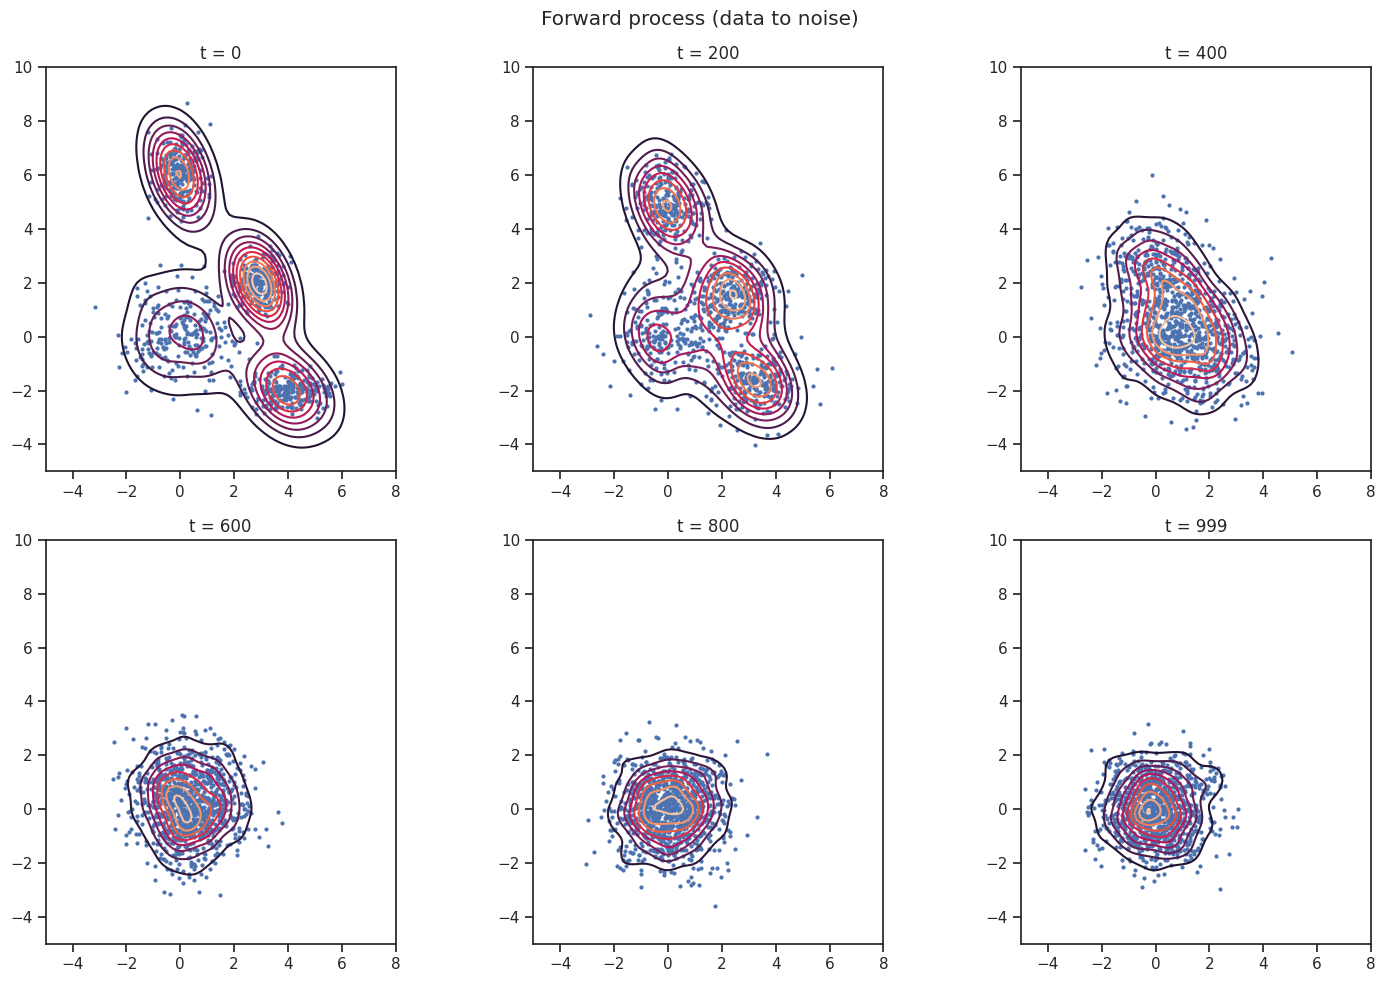

In [13]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

class DDPMForwardProcess:
    def __init__(self, num_timesteps=1000):
        self.num_timesteps = num_timesteps

        # Standard beta schedule from DDPM paper
        scale = 1000 / num_timesteps
        beta_start = scale * 0.0001
        beta_end = scale * 0.02
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps)

        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_betas = torch.sqrt(self.betas)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - self.alphas_cumprod)

    def forward_process(self, x_0, t):
        epsilon = torch.randn_like(x_0)
        mean = self.sqrt_alphas_cumprod[t] * x_0
        std = self.sqrt_one_minus_alphas_cumprod[t]
        return mean + std * epsilon, epsilon

    def visualize_forward_process(self, mixture, num_samples=1000):

        timesteps_to_show=[0, 200, 400, 600, 800, 999]
        x_0 = torch.FloatTensor(mixture.sample(num_samples))

        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        axes = axes.ravel()

        xx, yy = np.mgrid[-5:8:100j, -5:10:100j]
        positions = np.vstack([xx.ravel(), yy.ravel()])

        for idx, t in enumerate(timesteps_to_show):
            x_t, _ = self.forward_process(x_0, t)
            samples = x_t.numpy()

            from scipy.stats import gaussian_kde
            kernel = gaussian_kde(samples.T)
            density = np.reshape(kernel(positions).T, xx.shape)

            ax = axes[idx]

            ax.contour(xx, yy, density, levels=10, alpha=1.0)

            ax.scatter(samples[:, 0], samples[:, 1], alpha=1.0, s=4)

            ax.set_xlim(-5, 8)
            ax.set_ylim(-5, 10)
            ax.set_aspect('equal')
            ax.set_title(f't = {t}')

        plt.suptitle("Forward process (data to noise)")

        plt.tight_layout()
        plt.show()

ddpm = DDPMForwardProcess(num_timesteps=1000)
ddpm.visualize_forward_process(mixture)

## Dataset and Dataloader

In [14]:
from torch import nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import numpy as np

class ForwardDiffusionDataset(Dataset):
    def __init__(self, num_samples, input_dim,
                 T, mixture, beta_value=0.02):
        super().__init__()
        self.num_samples = num_samples
        self.input_dim = input_dim
        self.T = T
        self.beta_value = beta_value
        self.gm = mixture

        self.betas = beta_value * torch.ones(T)
        self.alphas = 1 - self.betas
        self.alpha_bar = torch.cumprod(self.alphas, dim=0)

        self.x0 = torch.FloatTensor(self.gm.sample(num_samples))

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        x0_sample = self.x0[idx]
        t = torch.randint(low=1, high=self.T + 1, size=(1,)).item()
        eps = torch.randn(self.input_dim)
        sqrt_alpha_bar = torch.sqrt(self.alpha_bar[t - 1])
        sqrt_one_minus_alpha_bar = torch.sqrt(1 - self.alpha_bar[t - 1])

        x_t = sqrt_alpha_bar * x0_sample + sqrt_one_minus_alpha_bar * eps

        return x_t, torch.tensor(t, dtype=torch.float32), eps

## Design Network

In [15]:
class DdpmNet(nn.Module):
    def __init__(self, in_dim=2, time_dim=1, hidden_dim=128, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim + time_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x, t):
        t = t.unsqueeze(1)
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

## Initialization and Training

In [16]:
num_samples = 10000
input_dim = 2
T = 1000
dataset = ForwardDiffusionDataset(num_samples=num_samples, input_dim=input_dim, T=T, mixture=mixture, beta_value=0.02)
batch_size = 64
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# %% Training the DDPM model
time_dim = 1
hidden_dim = 128
model = DdpmNet(in_dim=input_dim, time_dim=time_dim, hidden_dim=hidden_dim, out_dim=input_dim)
optimizer = Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

epochs = 100
model.train()
for epoch in range(1, epochs + 1):
    epoch_loss = 0
    for x_t_batch, t_batch, eps_batch in data_loader:
        optimizer.zero_grad()
        # Normalize time t to range [0,1]
        t_norm = t_batch / T
        eps_pred = model(x_t_batch, t_norm)
        loss = loss_fn(eps_pred, eps_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(data_loader)
    print(f"Epoch {epoch}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/100, Loss: 0.2086
Epoch 2/100, Loss: 0.1352
Epoch 3/100, Loss: 0.1223
Epoch 4/100, Loss: 0.1197
Epoch 5/100, Loss: 0.1062
Epoch 6/100, Loss: 0.1140
Epoch 7/100, Loss: 0.1001
Epoch 8/100, Loss: 0.1075
Epoch 9/100, Loss: 0.1072
Epoch 10/100, Loss: 0.0996
Epoch 11/100, Loss: 0.0953
Epoch 12/100, Loss: 0.1007
Epoch 13/100, Loss: 0.0991
Epoch 14/100, Loss: 0.0984
Epoch 15/100, Loss: 0.0953
Epoch 16/100, Loss: 0.0988
Epoch 17/100, Loss: 0.0949
Epoch 18/100, Loss: 0.0990
Epoch 19/100, Loss: 0.0926
Epoch 20/100, Loss: 0.0947
Epoch 21/100, Loss: 0.0947
Epoch 22/100, Loss: 0.0938
Epoch 23/100, Loss: 0.0941
Epoch 24/100, Loss: 0.0955
Epoch 25/100, Loss: 0.0911
Epoch 26/100, Loss: 0.0921
Epoch 27/100, Loss: 0.0950
Epoch 28/100, Loss: 0.0936
Epoch 29/100, Loss: 0.0958
Epoch 30/100, Loss: 0.0935
Epoch 31/100, Loss: 0.0933
Epoch 32/100, Loss: 0.0881
Epoch 33/100, Loss: 0.0951
Epoch 34/100, Loss: 0.0871
Epoch 35/100, Loss: 0.0969
Epoch 36/100, Loss: 0.0873
Epoch 37/100, Loss: 0.0886
Epoch 38/1

## Inference with the Reverse Process

In [17]:
n_infer = 1000

betas = 0.02 * torch.ones(T)
alphas = 1 - betas
alpha_bar = torch.cumprod(alphas, dim=0)

with torch.no_grad():
    x = torch.randn(n_infer, input_dim)

    record_steps = {999, 500, 200, 100, 50, 1}
    snapshots = {}

    for t in range(T, 0, -1):

        t_tensor = (torch.ones(n_infer) * t / T).float()
        eps_theta = model(x, t_tensor)

        beta_t = betas[t - 1]
        alpha_t = alphas[t - 1]
        alpha_bar_t = alpha_bar[t - 1]

        coef = beta_t / torch.sqrt(1 - alpha_bar_t)
        x = (1 / torch.sqrt(alpha_t)) * (x - coef * eps_theta)

        if t > 1:
            sigma_t = torch.sqrt(beta_t)
            x = x + sigma_t * torch.randn_like(x)

        if t in record_steps:
            snapshots[t] = x.clone().cpu().numpy()

## Visualize the Sampled Trajectories

In [19]:
import matplotlib.pyplot as plt

def get_angle_colors(positions):
    angles = np.arctan2(positions[:, 1], positions[:, 0])
    angles_deg = (np.degrees(angles) + 360) % 360
    colors = np.zeros((len(positions), 3))
    for i, angle in enumerate(angles_deg):
        segment = int(angle / 120)
        local_angle = angle - segment * 120
        if segment == 0:    # 0 degrees to 120 degrees (R->G)
            colors[i] = [1 - local_angle/120, local_angle/120, 0]
        elif segment == 1:  # 120 degrees to 240 degrees (G->B)
            colors[i] = [0, 1 - local_angle/120, local_angle/120]
        else:               # 240 degrees to 360° (B->R)
            colors[i] = [local_angle/120, 0, 1 - local_angle/120]

    return colors

def visualize_snapshots(snapshots):

    sorted_steps = sorted(snapshots.keys(), reverse=True)
    n_plots = len(sorted_steps)

    fig, axes = plt.subplots(2, 3, figsize=(5 * 3, 8))
    axes = axes.ravel()

    if n_plots == 1:
        axes = [axes]

    # Create grid for density visualization
    xx, yy = np.mgrid[-5:8:100j, -5:10:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])

    idx = 0
    for ax, t in zip(axes, sorted_steps):

        samples = snapshots[t]

        if idx == 0:
            c = get_angle_colors(samples)
            idx += 1

        x_0 = torch.FloatTensor(mixture.sample(num_samples))
        x_t, _ = ddpm.forward_process(x_0, t)
        samples_ = x_t.numpy()

        from scipy.stats import gaussian_kde
        kernel = gaussian_kde(samples_.T)
        density = np.reshape(kernel(positions).T, xx.shape)

        ax.contour(xx, yy, density, levels=10, alpha=0.8)

        ax.scatter(samples[:, 0], samples[:, 1], alpha=1.0, s=5, color=c)
        ax.set_title(f"t = {t}")
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.grid(True)

    plt.suptitle("Diffusion Model Reverse Process")
    plt.tight_layout()
    plt.show()

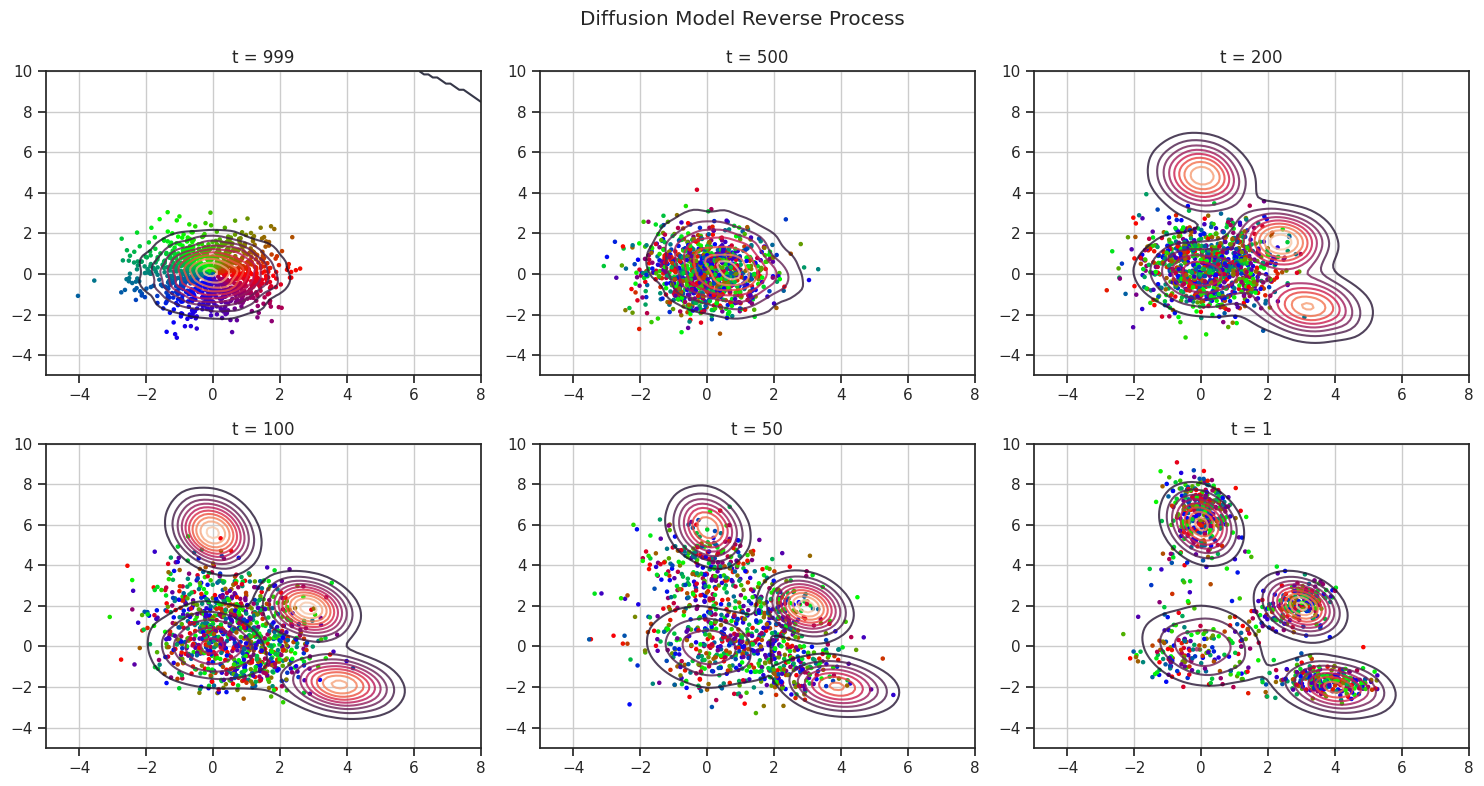

In [20]:
visualize_snapshots(snapshots)